<a href="https://colab.research.google.com/github/AlessandroCaforio/Python-for-ML-and-Econometrics/blob/main/classifiers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
from sklearn import datasets
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from IPython.display import display


In [20]:
data = datasets.load_iris()
iris = pd.DataFrame(data = data.data, columns = data.feature_names)
iris['target'] = data.target
X = iris.iloc[:, [2,3]]
y = iris['target']
print("Class labels:", np.unique(y))
print("Columns iris:", iris.columns)
print("Columns X", X.columns)


Class labels: [0 1 2]
Columns iris: Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')
Columns X Index(['petal length (cm)', 'petal width (cm)'], dtype='object')


In [14]:
# Vediamo i nomi delle classi contenuti nel dataset originale
class_names = data.target_names
print("Nomi delle classi:", class_names)

# Possiamo mappare i target numerici ai nomi per una migliore leggibilità
iris['species_name'] = iris['target'].map(lambda x: class_names[x])

# Visualizziamo le prime righe con i nomi delle specie
display(iris[['target', 'species_name']].drop_duplicates())

Nomi delle classi: ['setosa' 'versicolor' 'virginica']


,target,species_name
0,0,setosa
50,1,versicolor
100,2,virginica


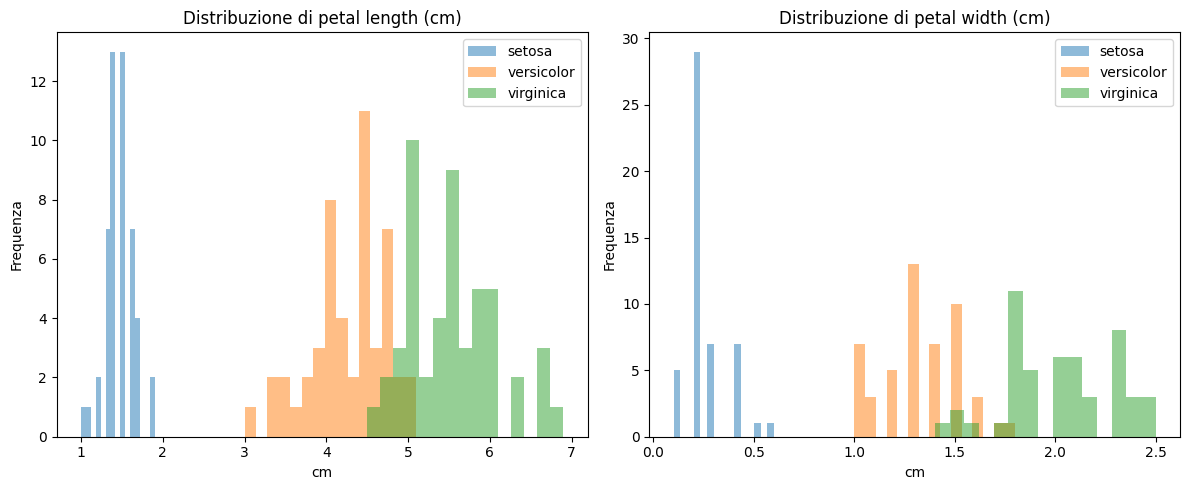

In [18]:
# Configuriamo i sottoplot: uno per la lunghezza e uno per la larghezza del petalo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
features = X.columns

for i, feature in enumerate(features):
    for target_val, target_name in enumerate(class_names):
        # Selezioniamo i dati per la classe specifica e la caratteristica corrente
        subset = X[y == target_val][feature]
        axes[i].hist(subset, label=target_name, alpha=0.5, bins=15)

    axes[i].set_title(f'Distribuzione di {feature}')
    axes[i].set_xlabel('cm')
    axes[i].set_ylabel('Frequenza')
    axes[i].legend()

plt.tight_layout()
plt.show()

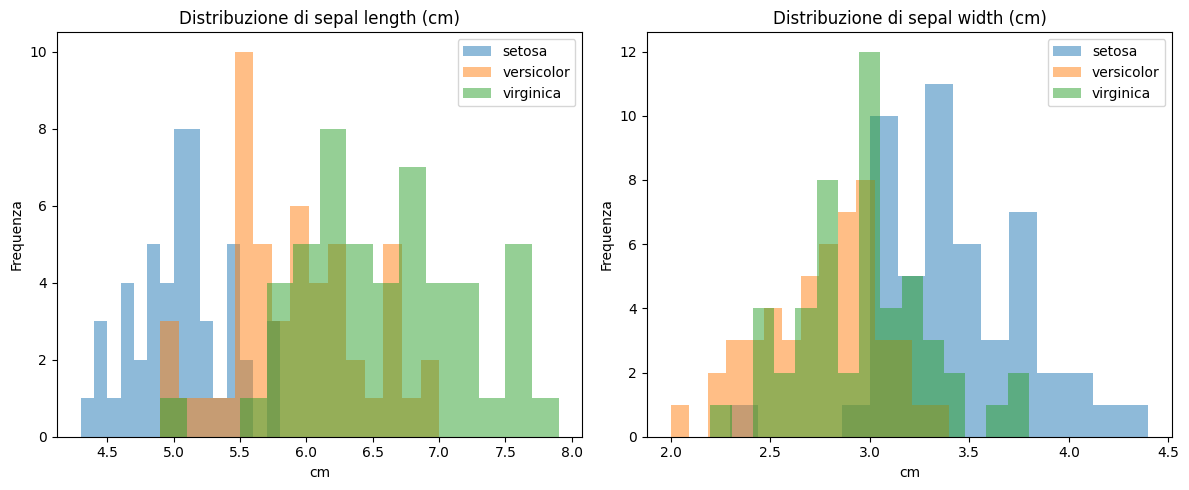

In [24]:
W = iris.iloc[:,[0,1]]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
features = W.columns

# Correzione del ciclo enumerate
for i, col_name in enumerate(features):
    for target_val, target_name in enumerate(class_names):
        subset = W[y == target_val][col_name]
        axes[i].hist(subset, label=target_name, alpha=0.5, bins=15)

    axes[i].set_title(f'Distribuzione di {col_name}')
    axes[i].set_xlabel('cm')
    axes[i].set_ylabel('Frequenza')
    axes[i].legend()

plt.tight_layout()
plt.show()

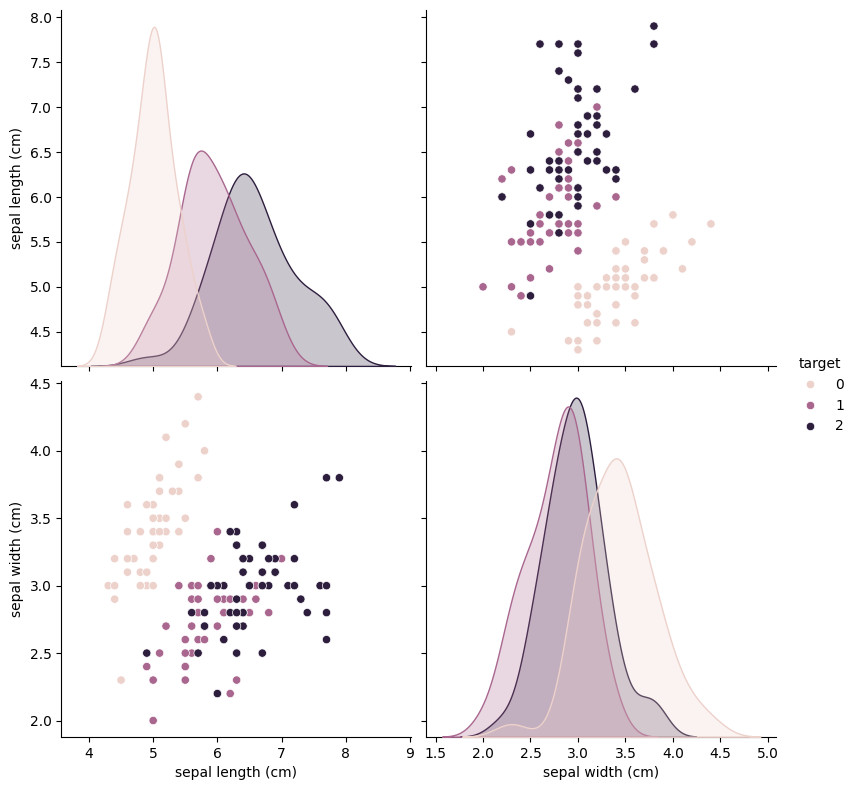

In [27]:
import seaborn as sns

# Un modo alternativo molto più rapido usando Seaborn:
# 'hue' divide automaticamente i dati per specie
sns.pairplot(iris, vars=['sepal length (cm)', 'sepal width (cm)'], hue='target', height=4)
plt.show()

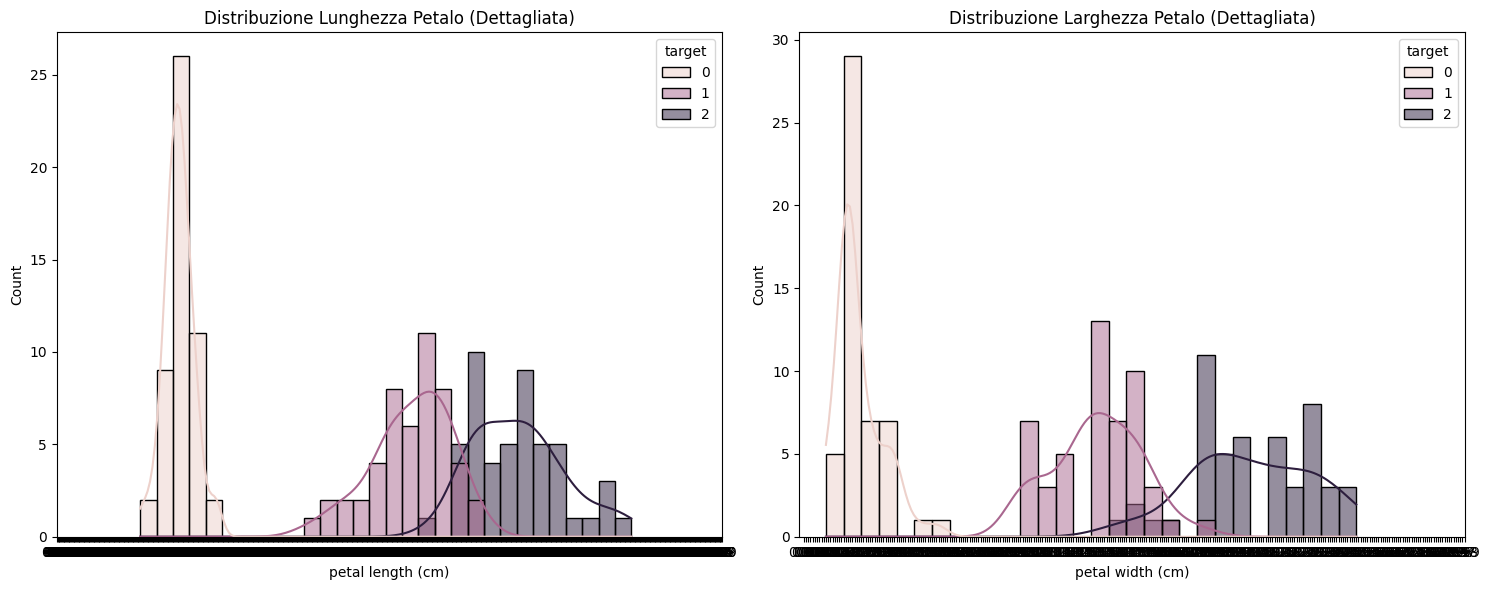

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Creiamo la griglia
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Primo grafico: Petal Length
sns.histplot(data=iris, x='petal length (cm)', hue='target', kde=True, ax=axes[0], bins=30)
axes[0].set_title('Distribuzione Lunghezza Petalo (Dettagliata)')
# Impostiamo i ticks ogni 0.5 cm
axes[0].set_xticks(np.arange(0, 8, 0.01))

# Secondo grafico: Petal Width
sns.histplot(data=iris, x='petal width (cm)', hue='target', kde=True, ax=axes[1], bins=30)
axes[1].set_title('Distribuzione Larghezza Petalo (Dettagliata)')
# Impostiamo i ticks ogni 0.2 cm
axes[1].set_xticks(np.arange(0, 3, 0.01))

plt.tight_layout()
plt.show()

In [33]:
from sklearn.model_selection import train_test_split
# The stratify methods help us returning training and test witht he same proportions of class labels as teh input dataset.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3,
                                                    random_state = 1, stratify = y)


In [39]:
print("Lables counts in y:", np.bincount(y))
print("Lables counts in y_train:", np.bincount(y_train))
print("Lables counts in y_test:", np.bincount(y_test))

Lables counts in y: [50 50 50]
Lables counts in y_train: [35 35 35]
Lables counts in y_test: [15 15 15]


In [46]:
## Many machine learning and optimization algortithms also require feature sclaing for optimal performance.

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(X_train)

X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test) ## Note that we use the same "X_train", so that the values in both trainin and test dataset are comparable.

Now that we have prepared the data we can think of training a classificaiton model. Remember that here we are not doing a binary classification, so we need a multiclass model

In [47]:
from sklearn.linear_model import Perceptron
ppino = Perceptron (eta0 = 0.1, random_state = 1)
ppino.fit(X_train_std, y_train)
y_pred = ppino.predict(X_test_std)
print("Misclassified examples: %d" % (y_test != y_pred).sum())

Misclassified examples: 1


In [49]:
from sklearn.metrics import accuracy_score
print('Accuracy: %.3f' % accuracy_score(y_test, y_pred))
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.3f}')

Accuracy: 0.978
Accuracy: 0.978


In [66]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

def plot_decision_regions( X, y, classifier, test_idx = None, resolution = 0.02):
  # Setup marker generator and color map:
  markers = ('s', 'x', 'o', '^', 'v')
  colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
  cmap = ListedColormap(colors[: len(np.unique(y))])

  #Plot the decision surface
  x1_min, x1_max = X[:, 0].min() -1, X[:, 0].max() +1
  x2_min, x2_max = X[:, 1].min() -1 , X[:,1].max() + 1
  xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution), np.arange(x2_min, x2_max, resolution))
  Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
  Z = Z.reshape(xx1.shape)
  plt.contourf(xx1, xx2, Z, alpha = 0.3, cmap = cmap)
  plt.xlim(xx1.min(), xx1.max())
  plt.ylim(xx2.min(), xx2.max())

  for idx, cl in enumerate(np.unique(y)):
    plt.scatter(x=X[y== cl,0], y = X[y == cl, 1], alpha = 0.8, c = colors[idx],
                marker = markers[idx], label=cl, edgecolor = 'black')

  #Highlight test examples:
  if test_idx:
    #plot all examples:
    X_test, y_test = X[test_idx, :], y[test_idx]

    plt.scatter(X_test[:, 0], X_test[:,1],
                c= '', edgecolor = 'black', alpha = 1.0,
                linewidth =1, marker = 'o',
                s = 100, label = 'test set')

/tmp/ipykernel_3808/1060012715.py:21: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y== cl,0], y = X[y == cl, 1], alpha = 0.8, c = colors[idx],


ValueError: 'c' argument must be a color, a sequence of colors, or a sequence of numbers, not ''

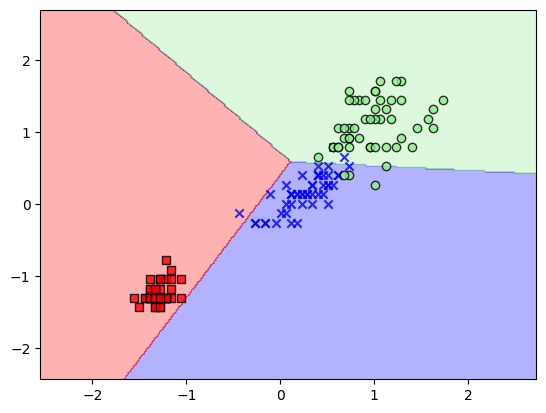

In [67]:
X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))
plot_decision_regions(X = X_combined_std,
                      y = y_combined,
                      classifier = ppino,
                      test_idx = range(105, 150))
plt.xlabel('petal length [standardized]')
plt.ylabel('petal width [standardized]')
plt.legend(loc = 'upper left')
plt.tight_layout()
plt.show()


In [ ]:
_